<a href="https://colab.research.google.com/github/8381014930/AI-Powered-Emotion-Detection-From-Text/blob/main/AI_Powered_Emotion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing Required Libraries

In [ ]:
!pip install datasets

In [ ]:
!pip install pandas numpy scikit-learn nltk seaborn matplotlib torch transformers datasets

## Loading The Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv
Saving validation.csv to validation (1).csv


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "csv",
    data_files={
        "train": "train.csv",
        "validation": "validation.csv",
        "test": "test.csv"
    }
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
dataset['train']
dataset['validation']
dataset['test']

Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})

In [ ]:
train_df = dataset['train'].to_pandas()
val_df   = dataset['validation'].to_pandas()
test_df  = dataset['test'].to_pandas()

In [ ]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


## Data Cleaning

In [ ]:
train_df.isnull().sum()

,0
text,0
label,0


In [ ]:
train_df.duplicated().sum()

np.int64(1)

In [ ]:
train_df.drop_duplicates(inplace=True)

In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df.describe()

,label
count,15999.000000
mean,1.565973
std,1.501471
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [ ]:
print(dataset["train"][:5])

{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'], 'label': [0, 0, 3, 2, 3]}


In [ ]:
dataset["train"].features

{'text': Value('string'), 'label': Value('int64')}

In [ ]:
len(dataset['train'])

16000

In [ ]:
sum([1 for x in dataset['train'] if x['text'] is None])

0

In [ ]:
from datasets import ClassLabel

class_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

dataset = dataset.cast_column("label", ClassLabel(names=class_names))

In [ ]:

dataset["train"].features["label"].names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
from collections import Counter

labels = dataset["train"]["label"]
label_counts = Counter(labels)

for label_id, count in label_counts.items():
    emotion = dataset["train"].features["label"].names[label_id]
    print(f"{emotion}: {count}")

sadness: 4666
anger: 2159
love: 1304
surprise: 572
fear: 1937
joy: 5362


## Exploratory Data Analysis(EDA)

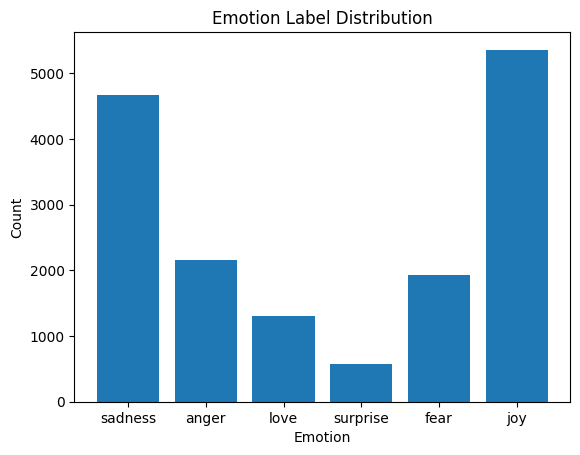

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

labels = dataset["train"]["label"]

# Count labels
label_counts = Counter(labels)

# Map label IDs to emotion names
label_names = dataset["train"].features["label"].names

emotions = [label_names[i] for i in label_counts.keys()]
counts = [label_counts[i] for i in label_counts.keys()]

# Plot
plt.bar(emotions, counts)
plt.title("Emotion Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

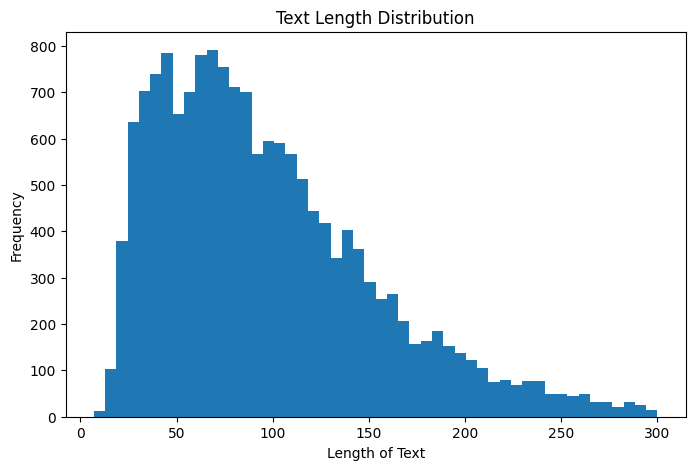

In [ ]:
train_df['text_length'] = train_df['text'].apply(len)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length of Text")
plt.ylabel("Frequency")
plt.show()

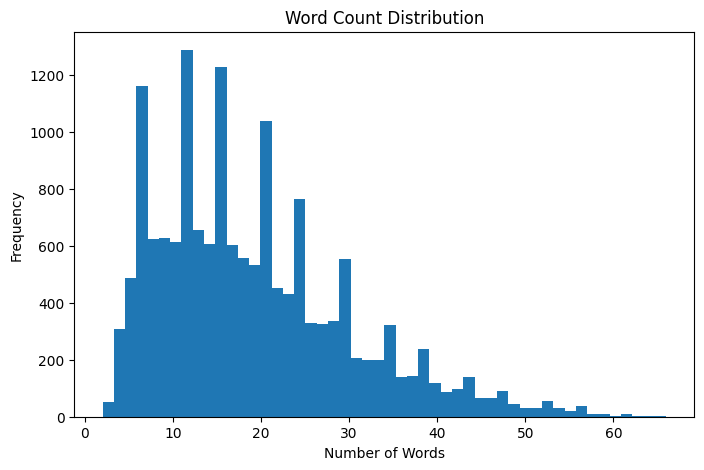

In [ ]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(train_df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

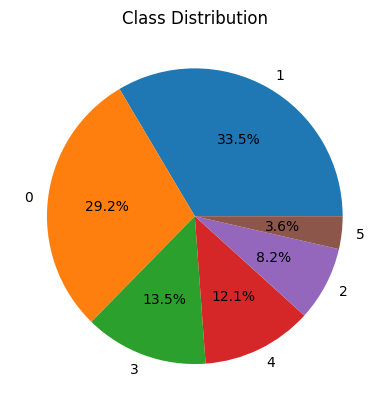

In [ ]:
train_df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class Distribution")
plt.ylabel('')
plt.show()

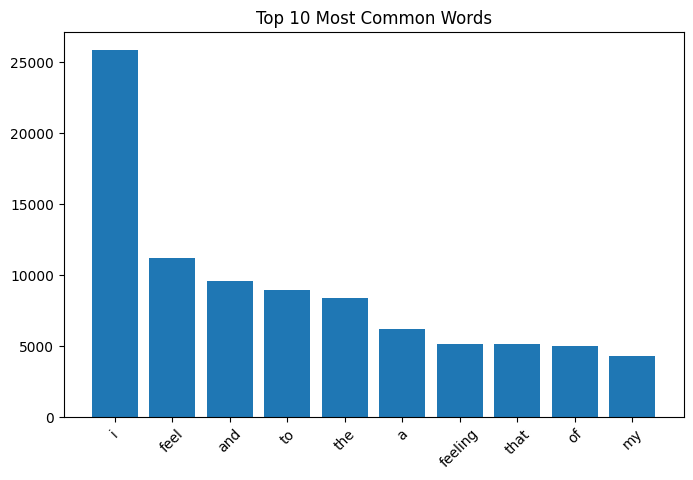

In [ ]:
from collections import Counter

all_words = " ".join(train_df['text']).split()
common_words = Counter(all_words).most_common(10)

words, counts = zip(*common_words)

plt.figure(figsize=(8,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Most Common Words")
plt.show()

## 1. TF-IDF + Logistic Regression Model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Train
X_train = dataset["train"]["text"]
y_train = dataset["train"]["label"]

X_test = dataset["test"]["text"]
y_test = dataset["test"]["label"]

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
test_acc_lr = accuracy_score(y_test, y_pred)

print("Logistic Regression Test Accuracy:", test_acc_lr)

Logistic Regression Test Accuracy: 0.8865


In [ ]:
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

print(classification_report(
    y_test,
    y_pred,
    target_names=label_names
))

              precision    recall  f1-score   support

     sadness       0.91      0.94      0.93       581
         joy       0.86      0.96      0.91       695
        love       0.83      0.64      0.72       159
       anger       0.92      0.83      0.87       275
        fear       0.90      0.85      0.88       224
    surprise       0.94      0.52      0.67        66

    accuracy                           0.89      2000
   macro avg       0.89      0.79      0.83      2000
weighted avg       0.89      0.89      0.88      2000



## 2. LSTM Model

In [ ]:
X_train = dataset["train"]["text"]
y_train = dataset["train"]["label"]

X_val = dataset["validation"]["text"]
y_val = dataset["validation"]["label"]

X_test = dataset["test"]["text"]
y_test = dataset["test"]["label"]

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 15000
max_len = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

In [ ]:
import numpy as np

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(vocab_size, 128),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),

    Bidirectional(LSTM(64)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val)
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.4655 - loss: 1.3690 - val_accuracy: 0.7130 - val_loss: 0.8007
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.8173 - loss: 0.5516 - val_accuracy: 0.8735 - val_loss: 0.3772
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9062 - loss: 0.2930 - val_accuracy: 0.9110 - val_loss: 0.2953
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9379 - loss: 0.2014 - val_accuracy: 0.9040 - val_loss: 0.3095
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9524 - loss: 0.1555 - val_accuracy: 0.9055 - val_loss: 0.3524
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9632 - loss: 0.1227 - val_accuracy: 0.9160 - val_loss: 0.2742
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9685 - loss: 0.1046 - val_accuracy: 0.9155 - val_loss: 0.3400
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9760 - loss: 0.0818 - 

In [ ]:
test_loss, test_acc_lstm = model.evaluate(X_test_pad, y_test)
print("LSTM Test Accuracy:", test_acc_lstm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9060 - loss: 0.3830
LSTM Test Accuracy: 0.906000018119812


In [ ]:
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
num_labels = 6

## 3. DISTILBERT Model

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)

tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

## DISTILBERT Model Training

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.261945,0.192311,0.929000
2,0.152480,0.156598,0.939500
3,0.098515,0.154787,0.937000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.25700999577840167, metrics={'train_runtime': 605.966, 'train_samples_per_second': 79.212, 'train_steps_per_second': 4.951, 'total_flos': 1589722177536000.0, 'train_loss': 0.25700999577840167, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate(tokenized_dataset["test"])

test_acc_bert = results["eval_accuracy"]

print("DistilBERT Test Accuracy:", test_acc_bert)

DistilBERT Test Accuracy: 0.926


## Confusion Matrix

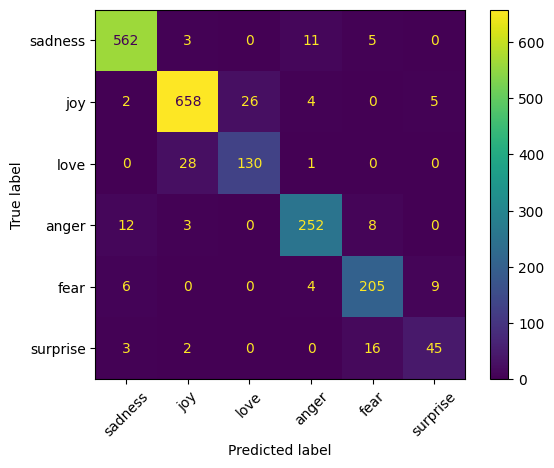

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds = trainer.predict(tokenized_dataset["test"])

y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(xticks_rotation=45)
plt.show()

In [ ]:
trainer.save_model("./emotion_model")
tokenizer.save_pretrained("./emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./emotion_model/tokenizer_config.json', './emotion_model/tokenizer.json')

## Models Comparison

In [ ]:
import pandas as pd

performance_df = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "LSTM", "DistilBERT"],
    "Accuracy": [test_acc_lr, test_acc_lstm, test_acc_bert],
    "Type": ["Traditional ML", "Deep Learning", "Transformer"],
    "Training Time": ["Fast", "Medium", "Slow"],
    "Performance Level": ["Very Good", "Very Good", "Best"]
})

performance_df

,Model,Accuracy,Type,Training Time,Performance Level
0,TF-IDF + Logistic Regression,0.8865,Traditional ML,Fast,Very Good
1,LSTM,0.9060,Deep Learning,Medium,Very Good
2,DistilBERT,0.9260,Transformer,Slow,Best


## Deployment

In [ ]:
from transformers import pipeline
from IPython.display import display, HTML

classifier = pipeline(
    "text-classification",
    model="./emotion_model",
    tokenizer="./emotion_model"
)

label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

def predict_emotion_ui(text):
    result = classifier(text)[0]

    label_index = int(result["label"].split("_")[1])
    emotion = label_map[label_index].upper()
    confidence = result["score"]

    html_output = f"""
    <div style="
        font-family: Arial;
        width: 600px;
        margin: 20px auto;
        padding: 25px;
        border-radius: 30px;
        background: linear-gradient(135deg, #f5f7fa, #c3cfe2);
        box-shadow: 0 8px 20px rgba(0,0,0,0.2);
    ">
        <h2 style="text-align:center;">Emotion Detection</h2>

        <div style="
            background: white;
            padding: 15px;
            border-radius: 20px;
            margin-top: 10px;
        ">
            {text}
        </div>

        <div style="
            margin-top: 20px;
            padding: 20px;
            border-radius: 25px;
            background: linear-gradient(135deg, #d4edda, #a8e6cf);
            color: #155724;
            text-align: center;
            font-size: 18px;
        ">
            <b>Emotion:</b> {emotion} <br><br>
            <b>Confidence:</b> {confidence:.2f}
        </div>
    </div>
    """

    display(HTML(html_output))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
import ipywidgets as widgets
from IPython.display import display


text_input = widgets.Textarea(
    placeholder="Enter your text...",
    layout=widgets.Layout(width='600px', height='100px')
)

# Button
button = widgets.Button(description="Detect Emotion", button_style='success')

# Output
output = widgets.Output()

def on_click(b):
    with output:
        output.clear_output()
        text = text_input.value

        if text.strip() == "":
            print("Please enter some text!")
        else:
            predict_emotion_ui(text)

button.on_click(on_click)

display(text_input, button, output)

Textarea(value='', layout=Layout(height='100px', width='600px'), placeholder='Enter your text...')

Button(button_style='success', description='Detect Emotion', style=ButtonStyle())

Output()